# Strategy Comparison: Diversify vs Cluster vs Hybrid (v3)

Notebook ini membandingkan performa **AI + Graph Diversify**, **AI + Graph Cluster**, dan **AI + Graph Hybrid** dalam strategi V62.

**Strategy Hybrid:**
- 📈 **Bull Market (AI Signal = True):** Menggunakan **Graph Clustering** (mencari aset yang kurang berkorelasi untuk menangkap momentum).
- 📉 **Bear Market (AI Signal = False):** Menggunakan **Graph Diversification (MIS)** (mencari aset yang terfragmentasi untuk meminimalkan risiko).
- 🚫 **No Cash:** Selalu invested, hanya berganti gaya seleksi.

**Tujuan:**
- Melihat apakah adaptasi strategi terhadap regime market memberikan performa lebih baik dibanding strategi statis statis atau gating ke cash.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 1. Load Data & Setup

In [2]:
# Load cryptocurrency data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")
print(f"\nReturns shape: {returns.shape}")
print(f"Total trading days: {len(returns)}")

Data: 990 rows, 25 assets
Period: 2023-04-17 00:00:00 to 2025-12-31 00:00:00

Returns shape: (977, 25)
Total trading days: 977


## 2. Train AI Model

In [3]:
# Prepare features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

# Train model
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Optimized Threshold
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.linspace(0.3, 0.7, 41)
f_scores = [fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in thresholds]
opt_t = thresholds[np.argmax(f_scores)]

print(f"✓ Model trained. Optimized Threshold: {opt_t:.2f}")

✓ Model trained. Optimized Threshold: 0.54


## 3. Generate Probabilities

In [4]:
# Generate probabilities for all available data
X_all = features.dropna()
all_probs_raw = xgb_model.predict_proba(X_all)[:, 1]

# Create series with original probabilities
all_probs_orig = pd.Series(all_probs_raw, index=X_all.index)

# Reindex to match returns index with forward fill for missing dates
all_probs = all_probs_orig.reindex(returns.index, method='ffill')

# Check for any remaining NaN and backfill if needed
if all_probs.isna().any():
    all_probs = all_probs.fillna(method='bfill')

print(f"\n✓ Probabilities generated")
print(f"Coverage: {len(all_probs) / len(returns) * 100:.1f}%")


✓ Probabilities generated
Coverage: 100.0%


## 4. Portfolio Optimization & Selection Functions

In [5]:
def optimize_markowitz(selected_returns):
    """Optimize portfolio using Markowitz mean-variance"""
    if len(selected_returns.columns) == 0: 
        return {}
    if len(selected_returns.columns) == 1: 
        return {selected_returns.columns[0]: 1.0}
    
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    num_assets = len(mu)
    
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: 
            return 0
        return -(ret / risk)
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets
    
    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """Select assets using graph diversification"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    """Select assets using graph clustering"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    momentum = returns_window.mean()
    assets = list(momentum.sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

print("✓ Functions defined")

✓ Functions defined


## 5. Simulation Functions (Gated, Static, Hybrid)

In [6]:
def run_simulation_ai_gated(test_dates, returns, ai_probs, threshold, market_idx, 
                            selection_func, override_ma=None, fee=0.0025, 
                            g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Run AI-gated simulation - ALL DATES INCLUDED"""
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {} 
    risk_status = False 
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        try:
            prob = ai_probs.loc[date]
        except KeyError:
            prob = ai_probs.iloc[ai_probs.index.get_loc(date, method='ffill')]
            
        prev_risk_status = risk_status
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): 
            ai_signal = True
        elif risk_status and prob < (threshold - buffer): 
            ai_signal = False
        else: 
            ai_signal = risk_status
        
        final_signal = ai_signal
        if override_ma and market_ma is not None:
            try:
                current_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and not pd.isna(current_price):
                    is_uptrend = (current_price > ma_price)
                    if ai_signal == False and is_uptrend:
                        final_signal = True
            except KeyError: pass
        
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        target_weights = current_weights.copy()
        
        if not risk_status:
            if regime_changed or 'CASH' not in current_weights or current_weights.get('CASH', 0) < 0.99:
                target_weights = {'CASH': 1.0}
                days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= rebal_period:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window_rets = returns.iloc[max(0, loc_idx-g_lookback):loc_idx]
                    if len(window_rets) > 0:
                        selected = selection_func(window_rets)
                        if len(selected) > 0:
                            optimized_weights = optimize_markowitz(window_rets[selected])
                            if optimized_weights:
                                all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                                turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                                if regime_changed or turnover_est > turnover_buffer:
                                    target_weights = optimized_weights
                                    days_since_rebal = 0
                except: pass
            days_since_rebal += 1

        # Transaction costs
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        if turnover_actual > 0.001:
            val -= val * turnover_actual * fee
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        if 'CASH' in target_weights and target_weights['CASH'] > 0.99:
            new_weights_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                try:
                    r = returns.loc[next_date, asset]
                    r_asset = r if not pd.isna(r) else 0
                    day_ret += w * r_asset
                    new_weights_drifted[asset] = w * (1 + r_asset)
                except: new_weights_drifted[asset] = w
            total_w = sum(new_weights_drifted.values())
            if total_w > 0: new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Run static simulation - always invested"""
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {}
    days_since_rebal = 999
    
    for i, date in enumerate(test_dates[:-1]):
        target_weights = current_weights.copy()
        if days_since_rebal >= rebal_period:
            try:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[max(0, loc_idx-g_lookback):loc_idx]
                if len(window_rets) > 0:
                    selected = selection_func(window_rets)
                    optimized_weights = optimize_markowitz(window_rets[selected])
                    if optimized_weights:
                        all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                        turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                        if turnover_est > turnover_buffer:
                            target_weights = optimized_weights
                            days_since_rebal = 0
            except: pass
        days_since_rebal += 1
        
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        if turnover_actual > 0.001:
            val -= val * turnover_actual * fee
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        for asset, w in target_weights.items():
            try:
                r = returns.loc[next_date, asset]
                r_asset = r if not pd.isna(r) else 0
                day_ret += w * r_asset
                new_weights_drifted[asset] = w * (1 + r_asset)
            except: new_weights_drifted[asset] = w
        total_w = sum(new_weights_drifted.values())
        if total_w > 0: new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

def run_simulation_hybrid(test_dates, returns, ai_probs, threshold, market_idx, 
                         override_ma=None, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Run hybrid simulation - Cluster in Bull, Diversify in Bear, NO CASH"""
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    current_weights = {} 
    risk_status = False
    days_since_rebal = 999
    
    market_ma = None
    if override_ma:
        market_ma = market_idx.rolling(window=override_ma).mean()
    
    for i, date in enumerate(test_dates[:-1]):
        try: prob = ai_probs.loc[date]
        except KeyError: prob = ai_probs.iloc[ai_probs.index.get_loc(date, method='ffill')]
            
        prev_risk_status = risk_status
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): ai_status = True
        elif risk_status and prob < (threshold - buffer): ai_status = False
        else: ai_status = risk_status
        
        final_status = ai_status
        if override_ma and market_ma is not None:
            try:
                curr_price = market_idx.loc[date]
                ma_price = market_ma.loc[date]
                if not pd.isna(ma_price) and curr_price > ma_price: final_status = True
            except KeyError: pass
        
        risk_status = final_status
        regime_changed = (risk_status != prev_risk_status)
        target_weights = current_weights.copy()
        
        if regime_changed or days_since_rebal >= rebal_period:
            try:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[max(0, loc_idx-g_lookback):loc_idx]
                if len(window_rets) > 0:
                    # HYBRID CHOICE
                    if risk_status: # BULL
                        selected = get_assets_graph_cluster(window_rets)
                    else: # BEAR
                        selected = get_assets_graph_diversify(window_rets)
                    
                    if len(selected) > 0:
                        optimized_weights = optimize_markowitz(window_rets[selected])
                        if optimized_weights:
                            all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
                            turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
                            if regime_changed or turnover_est > turnover_buffer:
                                target_weights = optimized_weights
                                days_since_rebal = 0
            except: pass
        days_since_rebal += 1

        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        if turnover_actual > 0.001: val -= val * turnover_actual * fee
        
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        for asset, w in target_weights.items():
            try:
                r = (returns.loc[next_date, asset] if not pd.isna(returns.loc[next_date, asset]) else 0)
                day_ret += w * r
                new_weights_drifted[asset] = w * (1 + r)
            except: new_weights_drifted[asset] = w
        total_w = sum(new_weights_drifted.values())
        if total_w > 0: new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("✓ Simulation functions ready")

✓ Simulation functions ready


## 6. Run Simulations

In [7]:
# Run simulations for each year
years = [2023, 2024, 2025]
results = {}

for year in years:
    print(f"\nProcessing {year}...")
    test_dates = returns.loc[returns.index.year == year].index
    print(f"  → Test dates: {len(test_dates)} days ({test_dates[0]} to {test_dates[-1]})")
    
    # 1. Diversify Strategy
    print("  → Running Diversify Gated...")
    diversify = run_simulation_ai_gated(
        test_dates, returns, all_probs, opt_t, market_index,
        get_assets_graph_diversify, override_ma=200
    )
    
    # 2. Cluster Strategy
    print("  → Running Cluster Gated...")
    cluster = run_simulation_ai_gated(
        test_dates, returns, all_probs, opt_t, market_index,
        get_assets_graph_cluster, override_ma=200
    )
    
    # 3. Hybrid Strategy (NEW)
    print("  → Running Hybrid (Bull=Cluster, Bear=Diversify, No Cash)...")
    hybrid = run_simulation_hybrid(
        test_dates, returns, all_probs, opt_t, market_index,
        override_ma=200
    )
    
    # 4. Static Markowitz
    print("  → Running Static baseline...")
    static = run_simulation_static(
        test_dates, returns, 
        lambda x: list(x.columns)
    )
    
    results[year] = {
        'Diversify': diversify,
        'Cluster': cluster,
        'Hybrid': hybrid,
        'Static': static
    }
    
    print(f"  ✓ {year} completed:")
    print(f"    Diversify: {diversify['Portfolio_Value'].iloc[-1]:.2f}")
    print(f"    Cluster:   {cluster['Portfolio_Value'].iloc[-1]:.2f}")
    print(f"    Hybrid:    {hybrid['Portfolio_Value'].iloc[-1]:.2f}")
    print(f"    Static:    {static['Portfolio_Value'].iloc[-1]:.2f}")

print("\n✓ All simulations completed!")


Processing 2023...
  → Test dates: 246 days (2023-04-30 00:00:00 to 2023-12-31 00:00:00)
  → Running Diversify Gated...
  → Running Cluster Gated...
  → Running Hybrid (Bull=Cluster, Bear=Diversify, No Cash)...
  → Running Static baseline...
  ✓ 2023 completed:
    Diversify: 130.91
    Cluster:   171.70
    Hybrid:    139.17
    Static:    116.19

Processing 2024...
  → Test dates: 366 days (2024-01-01 00:00:00 to 2024-12-31 00:00:00)
  → Running Diversify Gated...
  → Running Cluster Gated...
  → Running Hybrid (Bull=Cluster, Bear=Diversify, No Cash)...
  → Running Static baseline...
  ✓ 2024 completed:
    Diversify: 101.82
    Cluster:   461.13
    Hybrid:    415.91
    Static:    123.22

Processing 2025...
  → Test dates: 365 days (2025-01-01 00:00:00 to 2025-12-31 00:00:00)
  → Running Diversify Gated...
  → Running Cluster Gated...
  → Running Hybrid (Bull=Cluster, Bear=Diversify, No Cash)...
  → Running Static baseline...
  ✓ 2025 completed:
    Diversify: 99.82
    Cluster:  

## 7. Calculate Performance Metrics

In [8]:
def calculate_metrics(portfolio_df):
    """Calculate comprehensive performance metrics"""
    if len(portfolio_df) == 0:
        return {'Total Return (%)': 0, 'Ann. Return (%)': 0, 'Volatility (%)': 0, 'Sharpe Ratio': 0, 'Max Drawdown (%)': 0}
    
    values = portfolio_df['Portfolio_Value']
    rets = values.pct_change().dropna()
    
    total_return = (values.iloc[-1] / values.iloc[0] - 1) * 100
    ann_return = ((1 + total_return/100) ** (252/max(len(rets), 1)) - 1) * 100
    volatility = rets.std() * np.sqrt(252) * 100 if len(rets) > 0 else 0
    sharpe = ann_return / volatility if volatility > 0 else 0
    
    cummax = values.cummax()
    drawdown = ((values - cummax) / cummax * 100)
    max_dd = drawdown.min()
    
    return {
        'Total Return (%)': total_return,
        'Ann. Return (%)': ann_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

# Calculate metrics for all strategies
metrics_summary = []
for year in years:
    for strategy_name in ['Diversify', 'Cluster', 'Hybrid', 'Static']:
        metrics = calculate_metrics(results[year][strategy_name])
        metrics['Year'] = year
        metrics['Strategy'] = strategy_name
        metrics_summary.append(metrics)

metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Year', 'Strategy', 'Total Return (%)', 'Ann. Return (%)', 
                         'Volatility (%)', 'Sharpe Ratio', 'Max Drawdown (%)']]

print("\n" + "="*80)
print("PERFORMANCE METRICS SUMMARY")
print("="*80)
print(metrics_df.to_string(index=False))
print("="*80)


PERFORMANCE METRICS SUMMARY
 Year  Strategy  Total Return (%)  Ann. Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
 2023 Diversify         30.912218        31.923594       18.778206      1.700034         -6.483041
 2023   Cluster         71.704288        74.376988       34.295855      2.168687        -26.654496
 2023    Hybrid         39.167031        40.487408       44.730292      0.905145        -37.922454
 2023    Static         16.194295        16.693651       25.672187      0.650262        -22.892754
 2024 Diversify          1.818781         1.252199       17.047222      0.073455        -16.908192
 2024   Cluster        361.126719       187.282255       36.572947      5.120787        -11.974932
 2024    Hybrid        315.912593       167.525887       45.581122      3.675335        -20.096699
 2024    Static         23.215355        15.503726       24.908195      0.622435        -31.642126
 2025 Diversify         -0.181630        -0.125779        9.329551     -0.013482

## 8. Visualisasi: Performance per Year

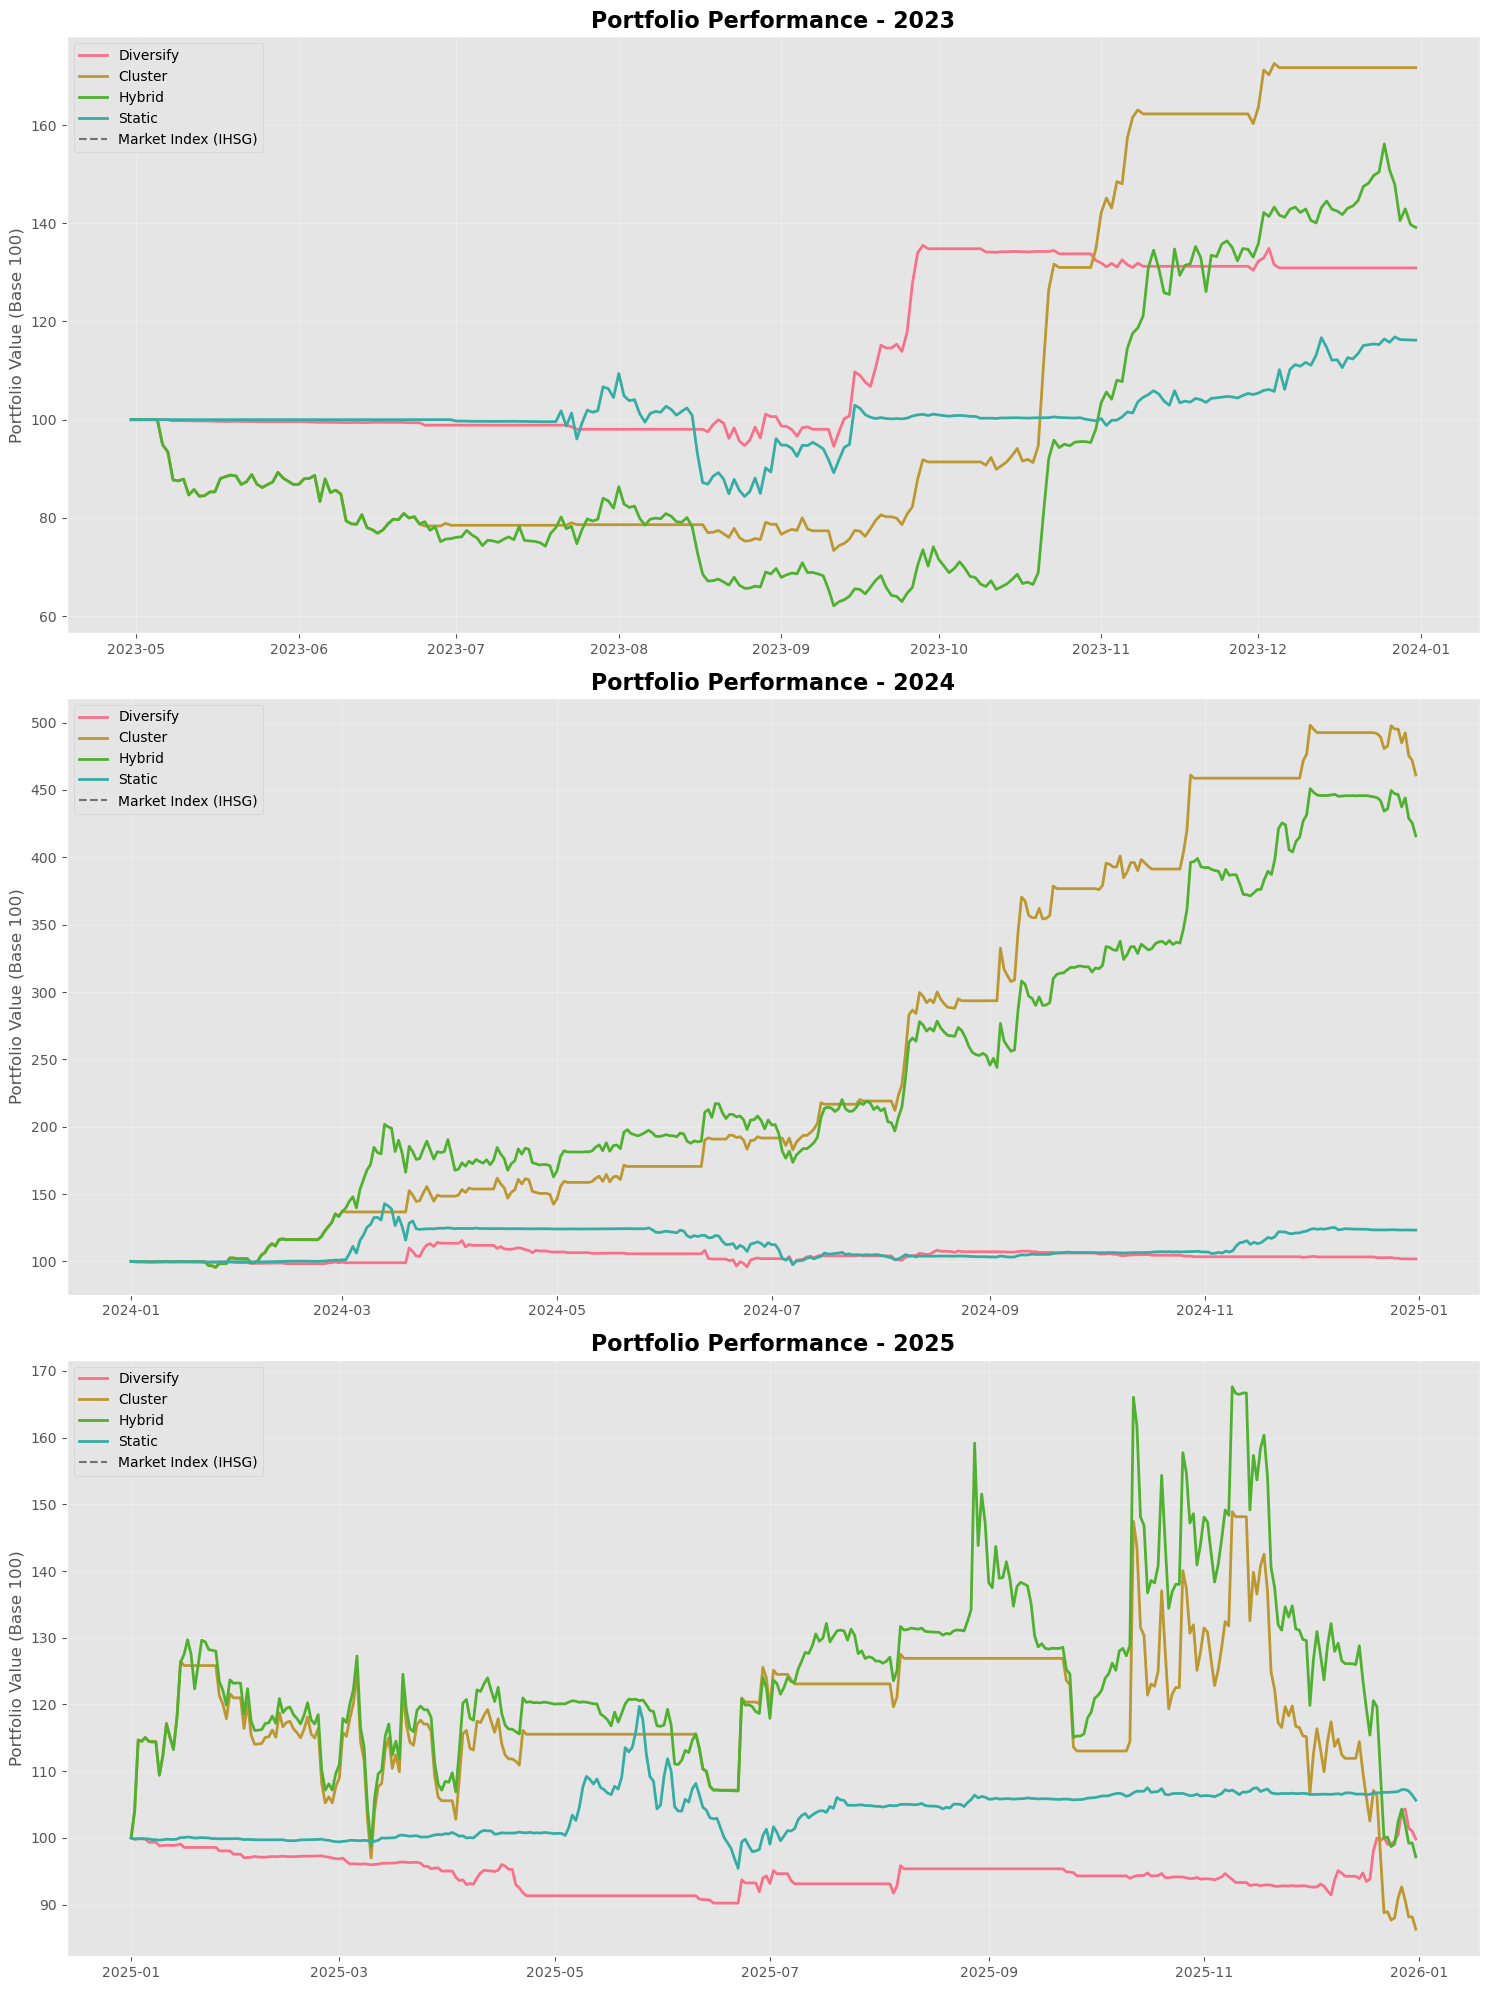

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

for i, year in enumerate(years):
    ax = axes[i]
    for strategy in ['Diversify', 'Cluster', 'Hybrid', 'Static']:
        ax.plot(results[year][strategy].index, results[year][strategy]['Portfolio_Value'], label=strategy, lw=2)
    
    # Market index as benchmark
    m_vals = market_index.loc[results[year]['Static'].index]
    m_vals = m_vals / m_vals.iloc[0] * 100
    ax.plot(m_vals.index, m_vals, label='Market Index (IHSG)', color='black', linestyle='--', alpha=0.5)
    
    ax.set_title(f"Portfolio Performance - {year}", fontsize=16, fontweight='bold')
    ax.set_ylabel("Portfolio Value (Base 100)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('strategy_comparison_by_year_v3.png', dpi=300)
plt.show()

## 9. Visualisasi: Metrics Comparison

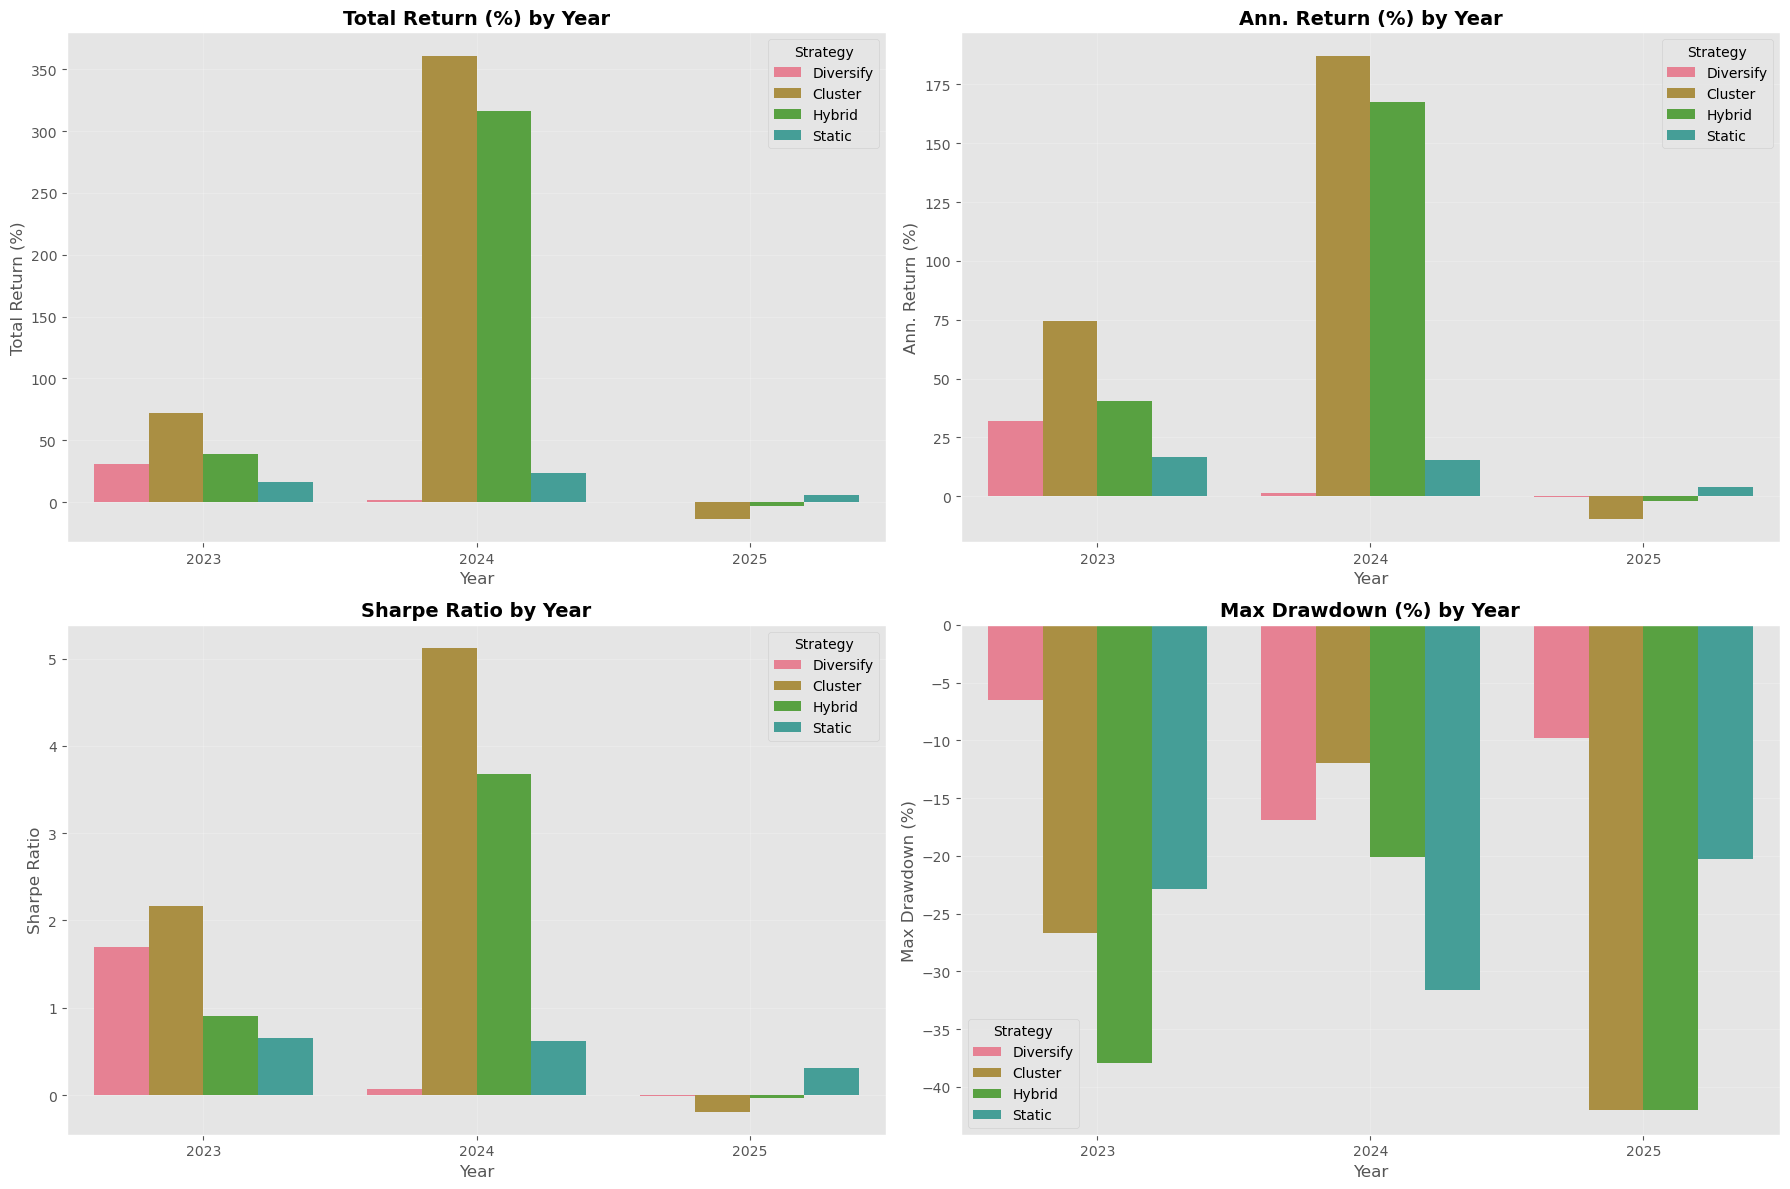

In [10]:
comparison_df = metrics_df.copy()
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metrics_to_plot = ['Total Return (%)', 'Ann. Return (%)', 'Sharpe Ratio', 'Max Drawdown (%)']
coords = [(0,0), (0,1), (1,0), (1,1)]

for metric, coord in zip(metrics_to_plot, coords):
    sns.barplot(data=comparison_df, x='Year', y=metric, hue='Strategy', ax=axes[coord])
    axes[coord].set_title(f"{metric} by Year", fontsize=14, fontweight='bold')
    axes[coord].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('diversify_vs_cluster_metrics_v3.png', dpi=300)
plt.show()

## 10. Average Performance

In [11]:
# Average metrics across years
avg_metrics = comparison_df.groupby('Strategy').mean(numeric_only=True)

print("\n" + "="*80)
print("AVERAGE PERFORMANCE (2023-2025)")
print("="*80)
print(avg_metrics.to_string())
print("="*80)


AVERAGE PERFORMANCE (2023-2025)
             Year  Total Return (%)  Ann. Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
Strategy                                                                                            
Cluster    2024.0        139.716321        83.991584       40.676164      2.366725        -26.884558
Diversify  2024.0         10.849790        11.016671       15.051660      0.586669        -11.055457
Hybrid     2024.0        117.414107        68.680109       48.738626      1.515063        -33.350809
Static     2024.0         15.021129        12.026090       21.112844      0.525629        -24.936669


## 11. Export Results

In [12]:
excel_filename = 'strategy_comparison_diversify_vs_cluster_v3_hybrid.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    metrics_df.to_excel(writer, sheet_name='All_Metrics', index=False)
    avg_metrics.to_excel(writer, sheet_name='Average_Metrics')
    
    for year in years:
        combined = pd.DataFrame({
            'Date': results[year]['Hybrid'].index,
            'Diversify': results[year]['Diversify']['Portfolio_Value'].values,
            'Cluster': results[year]['Cluster']['Portfolio_Value'].values,
            'Hybrid': results[year]['Hybrid']['Portfolio_Value'].values,
            'Static': results[year]['Static']['Portfolio_Value'].values
        })
        combined.to_excel(writer, sheet_name=f'Portfolio_{year}', index=False)

print(f"\n✓ Results exported to: {excel_filename}")


✓ Results exported to: strategy_comparison_diversify_vs_cluster_v3_hybrid.xlsx
